# Data Preprocessing

This notebook transforms raw satellite observations from two passive microwave sensors — **WindSat** and the **LPDR (AMSR-U)** product — into a machine-learning-ready tabular dataset covering the years 2017–2018.

The pipeline proceeds in five stages:

1. **Data download** — acquire WindSat NetCDF and LPDR GeoTIFF files.
2. **Reprojection** — warp LPDR files from the EASE-Grid v1 projection (EPSG:3410) onto the shared 0.25° geographic grid (EPSG:4326) used by WindSat.
3. **Harmonisation** — merge the two datasets pixel-by-pixel, apply atmospheric corrections and lookup-table emissivities, integrate the GLWD land mask, and apply quality filters.
4. **Data filing** — convert the daily NetCDF files to Parquet, adding cyclic temporal and spatial encodings ready for model ingestion.

## 0. Setup

### 0.1 Library loading

All third-party imports are collected here. The `osgeo` (GDAL) package is required only for Section 2 (Reprojection); if it is unavailable the rest of the notebook still runs.

In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import requests
import xarray as xr

from collections import defaultdict
from datetime import datetime, date, timedelta
from pathlib import Path
from scipy.ndimage import binary_dilation
from tqdm import tqdm
from typing import List
try:
    from osgeo import gdal, osr
except ImportError:
    # The osgeo/GDAL package is only required for the reprojection step (Section 3).
    # If it is not installed in the current environment, all other sections still work.
    print("Warning: osgeo/GDAL not available. Reprojection cell will not run.")

### 0.2 Configuration & constants

All tunable parameters, file paths, and dataset-selection settings are centralised below. Modifying a value here propagates automatically to every downstream cell.

| Constant | Description |
|---|---|
| `GRID_RES`, `GRID_NLAT`, `GRID_NLON` | Target grid resolution and dimensions (0.25°, 720 × 1440) |
| `VOD_RAW_MAX` | Upper bound of raw LPDR VOD values in Neper; used for normalisation to [0, 1] |
| `SM_BINS`, `VOD_BINS` | Bin edges for the De Lannoy et al. (2016) lookup tables |
| `REF_WATER_EMISS_H` | Open-water reference emissivity at 18.7 GHz H-pol (De Lannoy et al., 2016, Table 2) |
| `NODATA_VAL` | No-data sentinel value (−999) used throughout reprojection and masking |
| `WINDSAT_DIR` / `LPDR_RAW_DIR` / `LPDR_REP_DIR` | Input data directories |
| `COMPLETE_DIR` / `DATASET_DIR` | Output directories for merged NetCDF and Parquet files |
| `LUT_H_PATH` / `LUT_V_PATH` | Paths to the H- and V-polarisation lookup table CSVs |
| `LANDMASK_MAIN_PATH` / `LANDMASK_PCT_PATH` | Paths to the GLWD land-mask HDF5 files |
| `BASE_URL` | Base URL for the Remote Sensing Systems WindSat repository |
| `VARIABLES` | Mapping from LPDR band index to variable name (bands 2–7; band 1, the smoothed water fraction `fw`, is excluded) |
| `WINDSAT_VARS` | List of WindSat variables retained after subsetting |

In [2]:
# ── Time Coder ────────────────────────────────────────────────────────────────
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

In [3]:
# ── Spatial grid ──────────────────────────────────────────────────────────────
GRID_RES  = 0.25   # degrees – target resolution for LPDR reprojection
GRID_NLAT = 720    # 90°N to 90°S at 0.25°
GRID_NLON = 1440   # 180°W to 180°E at 0.25°

# ── Sensor parameters ─────────────────────────────────────────────────────────
VOD_RAW_MAX = 3.0  # Upper bound of raw LPDR VOD values (Neper); used for normalisation

# ── LUT bin edges (De Lannoy et al., 2016) ───────────────────────────────────
SM_BINS  = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
VOD_BINS = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0])

# ── Reference emissivity (De Lannoy et al., 2016, Table 2) ───────────────────
REF_WATER_EMISS_H = 0.288760  # Open-water emissivity at 18.7 GHz, H polarisation

# ── No-data sentinel ──────────────────────────────────────────────────────────
NODATA_VAL = -999.0

# ── File paths ────────────────────────────────────────────────────────────────
WINDSAT_DIR        = "data/windsat"
LPDR_RAW_DIR       = "data/lpdr/original"
LPDR_REP_DIR       = "data/lpdr/reprojected"
COMPLETE_DIR       = "data/complete"
LUT_H_PATH         = "data/lookup_tables/lut_de_lannoy_K_h.csv"
LUT_V_PATH         = "data/lookup_tables/lut_de_lannoy_K_v.csv"
LANDMASK_MAIN_PATH = "data/landmasks/GLWD_main_class_025deg.h5"
LANDMASK_PCT_PATH  = "data/landmasks/GLWD_all_classes_area_pct_025deg.h5"
DATASET_DIR        = "data/datasets"

# ── WindSat download URL ──────────────────────────────────────────────────────
BASE_URL = (
    "https://data.remss.com/TB/intercalibration/"
    "windsat_TB_maps_daily_025deg_unfiltered/"
)

# ── LPDR selected variables ───────────────────────────────────────────────────
VARIABLES = {
    2: 'fwns',
    3: 'Tmn',
    4: 'PWV',
    5: 'VOD',
    6: 'vsm',
    7: 'VPD',
}

# ── WindSat selected variables ────────────────────────────────────────────────
WINDSAT_VARS = [
    'tbtoa',
    'tran',
    'tbdw',
    'tbup',
    'surtep_ERA5'
]

### 0.3 Functions

All reusable helper functions are defined here. The `reproject_file` definition is included in this section for completeness; its execution loop runs in Section 2.

#### Reprojection

| Function | Signature | Purpose |
|---|---|---|
| `reproject_file` | `(file_path: str, output_folder: str)` → `bool` | Warps a single LPDR GeoTIFF from EPSG:3410 (EASE-Grid v1, cylindrical equal-area) to EPSG:4326 (geographic, equidistant cylindrical) at the target 1440 × 720 grid using GDAL nearest-neighbour resampling and a −999 no-data sentinel |

In [4]:
def reproject_file(file_path: str, output_folder: str = None) -> bool:
    """
        Read the input geotiff in EASE v1
        Reproject + resample into ED 0.25º
        create latitude an longitude bands for convenience.
        (bands added as second to last, and last band respectively)

        param output_folder: name of the new file to save reprojected data.
            If None, data will be ovewritten in file_path.

        Returns bool: whether or not the file was succesfully reprojected
    """
    dataset = gdal.Open(file_path)

    # Define the geotransform for the output dataset
    target_geotransform = (0, 0.25, 0.0, 90.0, 0.0, -0.25)

    output_width = 1440
    output_height = 720

    # Define src and geotransform from the input:
    source_srs = osr.SpatialReference()
    source_srs.ImportFromEPSG(3410)

    # Desired projection
    target_srs = osr.SpatialReference()
    target_srs.ImportFromEPSG(4326)

    # Declare the output file and driver:
    driver = gdal.GetDriverByName("GTiff")

    if output_folder is None:
        output_file = os.path.join(os.path.dirname(file_path), "temp.tif")

    else:
        output_file = os.path.join(output_folder, os.path.basename(file_path))

    # Create the new dataset
    output_dataset = driver.Create(
        output_file, output_width, output_height,
        dataset.RasterCount,
        gdal.GDT_Float32
    )
    output_dataset.SetProjection(target_srs.ExportToWkt())
    output_dataset.SetGeoTransform(target_geotransform)

    # Set the output dataset value to -999.0, instead of 0.
    for i in range(1, output_dataset.RasterCount, 1):
        band = output_dataset.GetRasterBand(i)
        arr = band.ReadAsArray()
        arr = arr - 999.0
        band.WriteArray(arr)

    # Reproject and resample using gdal.Warp()
    gdal.Warp(
        output_dataset,
        dataset,
        dstSRS=target_srs.ExportToWkt(),
        width=output_width,
        height=output_height,
        resampleAlg="near",
        # GRA_Bilinear TODO: bilinear warp does not work with Nodata params,
        # there will be values between -999 and the valid range
        srcNodata=float(-999.0),
        dstNodata=-999.0,
    )

    # Close the files
    dataset = None
    output_dataset = None

    if output_folder is None:
        # Delete original file, rename temp file.
        os.remove(file_path)
        os.rename(output_file, file_path)

    return True

#### Harmonisation helpers

The following functions implement the core preprocessing and harmonisation logic:

| Function | Signature | Purpose |
|---|---|---|
| `extract_amsru_variables` | `(ds, band_names)` → `xr.Dataset` | Extracts named variables from the multi-band LPDR `band_data` array |
| `reduce_windsat_dataset` | `(ds)` → `xr.Dataset` | Subsets WindSat to the descending fore swath, 18.7 & 37 GHz, V & H polarisations, and the variables listed in `WINDSAT_VARS` |
| `atmospheric_corrections` | `(ds: xr.Dataset)` → `xr.Dataset` | Adds `tbboa_1st_order` and `tbboa_de_lannoy` corrected brightness-temperature fields |
| `load_lut` | `(ds: xr.Dataset, lut_filepath: str)` → `xr.Dataset` | Bins each pixel by soil moisture and VOD, looks up the reference land emissivity from a De Lannoy et al. (2016) CSV table, and attaches it as `ref_land_emis_<pol>` |
| `unravel_freqpol` | `(ds: xr.Dataset, dvars: list[str])` → `xr.Dataset` | Flattens the `frequency_band × polarization` dimensions into individual named variables (e.g. `tbtoa19H`, `tbtoa37V`) |
| `preprocess_lpdr` | `(file_path: str)` → `xr.Dataset` | Full LPDR preprocessing: load, rename coordinates, extract variables, fix latitude orientation, normalise VOD |
| `preprocess_lpdr_quality_flag` | `(file_path: str)` → `xr.Dataset` | Loads the LPDR quality-flag GeoTIFF (band 1) and applies the same coordinate corrections as `preprocess_lpdr` |
| `preprocess_windsat` | `(file_path: str)` → `xr.Dataset` | Full WindSat preprocessing: load, create grid coordinate aliases, subset, rename polarisation dimension, apply atmospheric corrections |
| `load_landmask` | `(main_class_path: str, pct_class_path: str)` → `tuple` | Loads and latitude-sorts the two GLWD HDF5 files; returns `(lm, lm_pct)` for reuse across loop iterations |
| `apply_landmask` | `(ds, lm, lm_pct)` → `xr.Dataset` | Identifies coastal pixels via 8-connected binary dilation, adds them as a new class, and merges `clase` and percentage-area variables into `ds` |

In [5]:
def extract_amsru_variables(ds, band_names):
    lpdr_vars = {}

    for band, name in band_names.items():
        lpdr_vars[name] = (
            ds.band_data
            .sel(band=band)
            .drop_vars(['band', 'spatial_ref'])
        )

    return xr.Dataset(lpdr_vars)

def reduce_windsat_dataset(ds):
    # Subset using actual dimension names
    ds = ds.sel(
        indexers={
            "swath_sector": 1,             # Descending
            "look_direction": 0,           # Fore
            "polarization": [0, 1],  # [ V, H ]
            "frequency_band": [2, 4],  # [ 18.7 GHz (Ku) , 37.0 GHz (Ka) ]
        }
    )
    return ds[WINDSAT_VARS]

def atmospheric_corrections(ds: xr.Dataset) -> xr.Dataset:
    """
    Apply atmospheric correction to the brightness temperatures.

    Two formulas are implemented:

    **1st-order approximation**
        TBBoA = (TBToA - TBau) / tau
        where tau is the atmospheric transmittance and TBau is the upwelling
        atmospheric brightness temperature.

    **De Lannoy (2016) two-stream formula**
        TBBoA = Ts * [(TBToA / tau) - (1 + 1/tau) * TBau] / (Ts - TBau)
        where Ts is the ERA5 land surface skin temperature.

    Returns the same dataset with two new variables:
        - tbboa_1st_order
        - tbboa_de_lannoy
    """
    ds["tbboa_1st_order"] = (ds.tbtoa - ds.tbup) / ds.tran
    ds["tbboa_de_lannoy"] = (
        ds.surtep_ERA5
        * ((ds.tbtoa * (1 / ds.tran)) - ds.tbup * (1 + (1 / ds.tran)))
        / (ds.surtep_ERA5 - ds.tbup)
    )
    return ds

def load_lut(ds: xr.Dataset, lut_filepath: str,) -> xr.Dataset:
    """
    Read a lookup table CSV and attach the corresponding reference land
    emissivity to every pixel based on its soil-moisture and VOD bin.

    The LUT is indexed by (sm_bin, vod_bin) following De Lannoy et al. (2016).
    Bin edges are defined in SM_BINS and VOD_BINS in the configuration cell.

    Parameters
    ----------
    ds           : merged dataset containing 'vsm' and 'VOD' variables
    lut_filepath : path to the polarisation-specific CSV lookup table

    Returns
    -------
    ds with an added 'ref_land_emis_<pol>' variable
    (e.g. ref_land_emis_de_lannoy_K_h)
    """

    sm_bins  = SM_BINS
    vod_bins = VOD_BINS

    sm_slices  = [(sm_bins[i],  sm_bins[i+1])  for i in range(len(sm_bins)  - 1)]
    vod_slices = [(vod_bins[i], vod_bins[i+1]) for i in range(len(vod_bins) - 1)]

    # Recreate the bin indices used when generating the LUTs
    sm_idx  = np.full(ds.vsm.shape, np.nan)
    vod_idx = np.full(ds.VOD.shape, np.nan)

    for i, (sm_min, sm_max) in enumerate(sm_slices):
        sm_idx[(ds.vsm >= sm_min) & (ds.vsm < sm_max)] = i

    for j, (vod_min, vod_max) in enumerate(vod_slices):
        vod_idx[(ds.VOD >= vod_min) & (ds.VOD < vod_max)] = j

    sm_idx  = xr.DataArray(sm_idx,  dims=ds.vsm.dims)
    vod_idx = xr.DataArray(vod_idx, dims=ds.VOD.dims)

    # Assign bin indices as coordinates
    ds = ds.assign_coords(sm_bin=sm_idx, vod_bin=vod_idx)

    # Load LUT from CSV
    lut_df = pd.read_csv(lut_filepath, index_col=0)
    lut_xr = xr.DataArray(lut_df)

    # Replace NaN bins with -1 sentinel (required for integer indexing)
    ds["sm_bin"]  = ds["sm_bin"].fillna(-1).astype(int)
    ds["vod_bin"] = ds["vod_bin"].fillna(-1).astype(int)

    # Derive polarisation name from filename (e.g. "de_lannoy_K_h")
    pol_name = os.path.basename(lut_filepath).removeprefix("lut_").removesuffix(".csv")

    ds[pol_name] = (("sm_bin", "vod_bin"), lut_xr.values)

    # Map each pixel to its LUT reference emissivity value
    dvar_name = "ref_land_emis_" + pol_name
    ds[dvar_name] = ds[pol_name].sel(sm_bin=ds["sm_bin"], vod_bin=ds["vod_bin"]).astype(np.float32)

    # Drop the LUT matrix variable and its temporary sm_bin/vod_bin dimensions
    ds = ds.drop_dims(["sm_bin", "vod_bin"])

    # Nullify pixels where BOTH SM and VOD were outside the LUT valid range
    # (both bins set to -1 sentinel), matching the reference implementation.
    missing_vodsm = (ds.sm_bin == -1) & (ds.vod_bin == -1)
    ds = ds.where(~missing_vodsm)

    return ds

def unravel_freqpol(ds: xr.Dataset, dvars: list[str]) -> xr.Dataset:
    """
    FROM LST ATBD
    Unravel the frequency and polarization dimensions into
    a set of new data variables, for each dvar in list.
    Returns the dataset with added fields.
    """
    frequencies = {
        0: "19",
        1: "37",
    }
    polarizations = {
        0: "V",
        1: "H",
    }

    for dvar in dvars:

        if dvar not in ds.data_vars:
            print(f"Warning: {dvar} not found in dataset.")
            continue

        for freqid, freqname in frequencies.items():
            for polid, polname in polarizations.items():
                new_name = f"{dvar}{freqname}{polname}"
                ds[new_name] = ds[dvar].isel(
                    polarization=polid, frequency_band=freqid
                )

    return ds

# -- High-level preprocessing helpers -------------------------------------
def preprocess_lpdr(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single LPDR (AMSRU) reprojected GeoTIFF file.

    Steps:
    1. Load the GeoTIFF as an xarray Dataset.
    2. Rename spatial coordinates (x -> longitude_grid, y -> latitude_grid).
    3. Extract target variables from the band_data array using VARIABLES.
    4. Flip and sort latitude (EASE grid stores rows N->S; we want S->N).
    5. Normalise VOD from raw Neper range [0, VOD_RAW_MAX] to [0, 1].
    """
    ds = xr.open_dataset(file_path)
    ds = ds.rename({"x": "longitude_grid", "y": "latitude_grid"})
    ds = extract_amsru_variables(ds, VARIABLES)
    ds = ds.assign_coords(
        latitude_grid=-ds.latitude_grid[::-1].astype('float32')
    )
    ds = ds.sortby("latitude_grid")
    old_attrs = ds.VOD.attrs
    ds["VOD"] = ds.VOD / VOD_RAW_MAX
    old_attrs.update({
        "Valid_range": "0-1",
        "Description": f"NORMALIZED VOD, original is 0-{VOD_RAW_MAX} Neper"
    })
    ds.VOD.attrs = old_attrs
    return ds

def preprocess_lpdr_quality_flag(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single LPDR (AMSRU) reprojected GeoTIFF file.

    Steps:
    1. Load the GeoTIFF as an xarray Dataset.
    2. Rename spatial coordinates (x -> longitude_grid, y -> latitude_grid).
    3. Flip and sort latitude (EASE grid stores rows N->S; we want S->N).
    """
    ds = xr.open_dataset(file_path)
    ds = ds.rename({"x": "longitude_grid", "y": "latitude_grid"})
    lpdr_vars = {}
    lpdr_vars['quality_flag'] = ds.band_data.sel(band=1).drop_vars(['band', 'spatial_ref'])
    ds = xr.Dataset(lpdr_vars)
    ds = ds.assign_coords(
        latitude_grid=-ds.latitude_grid[::-1].astype('float32')
    )
    ds = ds.sortby("latitude_grid")
    return ds

def preprocess_windsat(file_path: str) -> xr.Dataset:
    """
    Load and preprocess a single WINDSAT daily NetCDF file.

    Steps:
    1. Load the NetCDF with CF-time decoding.
    2. Create longitude_grid / latitude_grid coordinate aliases.
    3. Subset to descending fore swath, 18.7 & 37 GHz, V & H polarisations.
    4. Rename polarization_dual -> polarization.
    5. Apply atmospheric corrections (1st-order and De Lannoy 2016).
    """
    ds = xr.open_dataset(file_path, decode_times=time_coder)
    ds = ds.assign_coords(
        longitude_grid=ds.longitude,
        latitude_grid=ds.latitude,
    )
    ds.latitude_grid.attrs["long_name"] = "latitude_grid"
    ds.longitude_grid.attrs["long_name"] = "longitude_grid"
    ds.latitude_grid.attrs["units"] = "degN"
    ds.longitude_grid.attrs["units"] = "degE"
    ds = reduce_windsat_dataset(ds)
    ds = ds.rename({'polarization_dual': 'polarization'})
    ds = atmospheric_corrections(ds)
    return ds

def load_landmask(main_class_path: str = None, pct_class_path: str = None,) -> tuple:
    """
    Load and prepare the two GLWD landmask datasets.

    Returns a (lm, lm_pct) tuple ready to be passed to apply_landmask().
    Loading is separated from merging so the datasets can be reused across
    all daily iterations without re-reading the files each time.
    """
    if main_class_path is None:
        main_class_path = LANDMASK_MAIN_PATH
    if pct_class_path is None:
        pct_class_path = LANDMASK_PCT_PATH

    lm     = xr.open_dataset(main_class_path, decode_times=time_coder)
    lm_pct = xr.open_dataset(pct_class_path,  decode_times=time_coder)

    for mask in [lm, lm_pct]:
        mask.latitude_grid.attrs["long_name"]  = "latitude_grid"
        mask.longitude_grid.attrs["long_name"] = "longitude_grid"
        mask.latitude_grid.attrs["units"]  = "degN"
        mask.longitude_grid.attrs["units"] = "degE"

    lm     = lm.sortby("latitude_grid")
    lm_pct = lm_pct.sortby("latitude_grid")
    return lm, lm_pct

def apply_landmask(ds: xr.Dataset, lm: xr.Dataset, lm_pct: xr.Dataset,) -> xr.Dataset:
    """
    Integrate the GLWD landmask into ds and add a 'coastal' class.

    The coastal class is identified via binary dilation: any land pixel
    adjacent (8-connectivity) to at least one sea pixel receives a new
    class value of max(existing_classes) + 1. This lets the model treat
    coastal pixels separately from open land and open ocean.

    Parameters
    ----------
    ds    : dataset to merge the landmask into
    lm    : GLWD main-class dataset (output of load_landmask)
    lm_pct: GLWD percentage-area dataset (output of load_landmask)

    Returns
    -------
    ds with 'clase' and all percentage-area variables merged in
    """
    da       = lm['clase']
    land     = ~np.isnan(da)
    sea      = np.isnan(da)
    sea_near = binary_dilation(sea, structure=np.ones((3, 3)))
    coastal  = land & sea_near
    new_class = int(np.nanmax(da.values)) + 1

    lm_with_coast = lm.copy(deep=True)
    lm_with_coast['clase'].values[coastal] = new_class

    ds = xr.merge([ds, lm_with_coast], join="exact")
    ds = xr.merge([ds, lm_pct],        join="exact")
    ds["clase"] = ds["clase"].astype(np.float32)
    ds["porcentaje clase"] = ds["porcentaje clase"].astype(np.float32)
    return ds

#### File pairing utilities

| Function | Signature | Purpose |
|---|---|---|
| `get_year_and_doy` | `(file_path)` → `(str, str)` | Parses the four-digit year and three-digit day-of-year from either an LPDR (`AMSRU_Mland_YYYYdddX.tif`) or WindSat (`RSS_WINDSAT_..._YYYY_MM_DD.nc`) filename |
| `group_files_by_day` | `(lpdr_dir, windsat_dir)` → `List[List[str]]` | Scans both directories, groups descending LPDR files and their quality-flag counterparts with the corresponding WindSat file by (year, DOY), and returns a sorted list of `[lpdr_path, qa_path, windsat_path]` triplets |

In [6]:
def get_year_and_doy(file_path):
    file_path = str(file_path)
    if 'AMSRU' in file_path:
        year_doy_str = os.path.basename(file_path).split('_')[2][:7]
        year = year_doy_str[:4]
        doy  = year_doy_str[4:]
    elif 'WINDSAT' in file_path:
        year, month, day = os.path.basename(file_path).split("_")[-3:]
        day = day.replace(".nc", "")
        date = datetime(int(year), int(month), int(day))
        year = str(year)
        doy  = f"{date.timetuple().tm_yday:03d}"
    return year, doy

def group_files_by_day(lpdr_dir: str, windsat_dir: str) -> List[List[str]]:
    # (year, doy) -> {"lpdr": ..., "qa": ..., "windsat": ...}
    grouped = defaultdict(lambda: {"lpdr": [], "qa": [], "windsat": []})

    # Collect LPDR files — descending pass only (D.tif), excluding QA files
    for path in Path(lpdr_dir).iterdir():
        if path.is_file():
            if path.stem.endswith("D_QA"):
                key = get_year_and_doy(path)
                grouped[key]["qa"].append(str(path))
            elif path.stem.endswith("D"):
                key = get_year_and_doy(path)
                grouped[key]["lpdr"].append(str(path))

    # Collect WINDSAT files
    for path in Path(windsat_dir).iterdir():
        if path.is_file():
            key = get_year_and_doy(path)
            grouped[key]["windsat"].append(str(path))

    # Build final list, sorted by (year, doy)
    output = []
    for key in sorted(grouped.keys()):
        year, doy = key
        lpdr_files    = sorted(grouped[key]["lpdr"])
        qa_files      = sorted(grouped[key]["qa"])
        windsat_files = sorted(grouped[key]["windsat"])

        # Sanity checks
        if len(lpdr_files) > 4:
            raise ValueError(f"More than 4 LPDR-D files for year {year} DOY {doy}")
        if len(qa_files) > 1:
            raise ValueError(f"More than 1 QA file for year {year} DOY {doy}")
        if len(windsat_files) > 1:
            raise ValueError(f"More than 1 WINDSAT file for year {year} DOY {doy}")

        # Pair only when both a WINDSAT file and a QA file exist
        if windsat_files and qa_files:
            output.append(lpdr_files + qa_files + windsat_files)

    return output

## 1. Data Download

### 1.1 WindSat data

WindSat daily brightness-temperature maps are downloaded from the [Remote Sensing Systems (RSS) intercalibration repository](https://data.remss.com). Each file covers one calendar day at 0.25° resolution and is approximately 1 GB uncompressed. The download loop below iterates over the full 2017–2018 period, skipping files that are already present on disk.

> **Note:** Download speeds from the RSS server are typically 7–15 minutes per file. It is advisable to run the loop in chunks by progressively advancing `end_date`, or to retrieve the data through an alternative means (e.g. `wget`, Globus).

In [8]:
start_date = date(2017, 1, 1)
end_date = date(2018, 12, 31)

current_date = start_date

while current_date <= end_date:
    datestr = current_date.strftime("%Y_%m_%d")
    filename = f"RSS_WINDSAT_DAILY_TBTOA_MAPS_{datestr}.nc"
    url = BASE_URL + filename
    local_path = os.path.join(WINDSAT_DIR, filename)

    if os.path.exists(local_path):
        print(f"Skipping (already exists): {filename}")
        current_date += timedelta(days=1)
        continue

    print(f"Downloading: {filename}")

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with open(local_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    except requests.RequestException as e:
        print(f"Failed to download {filename}: {e}")

    current_date += timedelta(days=1)

print("Download process completed.")

Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_02.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_03.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_04.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_05.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_06.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_07.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_08.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_09.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_10.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_11.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_12.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_13.nc
Skipping (already exists): RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_14.nc
Skipping (already ex

In [ ]:
# ── Download verification ────────────────────────────────────────────────────
_expected, _d = [], start_date
while _d <= end_date:
    _expected.append(_d)
    _d += timedelta(days=1)

corrupted, present = [], set()

for _d in _expected:
    _datestr = _d.strftime("%Y_%m_%d")
    _fname   = f"RSS_WINDSAT_DAILY_TBTOA_MAPS_{_datestr}.nc"
    _path    = os.path.join(WINDSAT_DIR, _fname)

    if os.path.exists(_path):
        try:
            ds = xr.open_dataset(_path, decode_times=time_coder)
            ds.close()
            present.add(_d)
        except Exception as e:
            print(f"CORRUPTED: {_fname}  →  {e}")
            corrupted.append(_fname)

missing = [_d for _d in _expected if _d not in present]

print(f"Files present : {len(present)}")
print(f"Corrupted     : {len(corrupted)}")
if corrupted:
    for f in corrupted:
        print(f"  - {f}")

print(f"\nMissing dates : {len(missing)}")
if missing:
    for _d in missing:
        print(f"  - {_d.strftime('%Y-%m-%d')}")
else:
    print("  None — all dates accounted for!")

Files present : 726
Corrupted     : 0

Missing dates : 4
  - 2017-08-09
  - 2017-08-10
  - 2017-08-11
  - 2018-11-04


730 daily files are expected (1 Jan 2017 – 31 Dec 2018). Four dates are missing from the RSS archive (2017-08-09, 2017-08-10, 2017-08-11, 2018-11-04) and will be absent from the final dataset.

#### Structure inspection

The cell below opens one downloaded NetCDF to understand its structure. 

In [7]:
windsat_ds = xr.open_dataset(f"{WINDSAT_DIR}/RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc", decode_times=time_coder)
windsat_ds

<xarray.Dataset> Size: 1GB
Dimensions:         (longitude_grid: 1440, latitude_grid: 720, swath_sector: 2,
                     look_direction: 2, frequency_band: 5, polarization: 4,
                     polarization_dual: 2)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band, polarization,
                                polarization_dual
Data variables: (12/34)
    longitude       (longitude_grid) float32 6kB ...
    latitude        (latitude_grid) float32 3kB ...
    node            (swath_sector) int32 8B ...
    look            (look_direction) int32 8B ...
    frequency_vpol  (frequency_band) float32 20B ...
    frequency_hpol  (frequency_band) float32 20B ...
    ...              ...
    colcld_WSAT     (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_IMERG      (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_WSAT       (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    tran            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbup            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbdw            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

### 1.2 LPDR data

The LPDR v3 GeoTIFF files are available from [NTSG's public data repository](http://files.ntsg.umt.edu). No automated download script is provided here because the server requires interactive authentication. The following `wget` command can be adapted to retrieve a full year (adjust the year in both `-I` and the target URL):

```bash
wget -w 0.5 -l 0 -r -nH -np \
  -I /data/LPDR_v3/GeoTif/2017/*,/data/LPDR_v3/GeoTif/2017 \
  -R "*.html,*.htm" \
  -P "data/lpdr/original" \
  files.ntsg.umt.edu/data/LPDR_v3/GeoTif/2017
```

Each daily file is a multi-band GeoTIFF containing 7 bands plus a quality-flag file (`*QA.tif`). Files follow the naming convention `AMSRU_Mland_YYYYdddP.tif`, where `ddd` is the three-digit day-of-year and `P` is `A` (ascending) or `D` (descending).

#### Structure inspection

A raw (pre-reprojection) file is loaded to inspect its properties.

In [8]:
lpdr_ds = xr.open_dataset(f"{LPDR_RAW_DIR}/AMSRU_Mland_2017001A.tif", decode_times=time_coder)
lpdr_ds

<xarray.Dataset> Size: 23MB
Dimensions:      (band: 7, x: 1383, y: 586)
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 11kB -1.732e+07 -1.73e+07 ... 1.73e+07 1.732e+07
  * y            (y) float64 5kB 7.332e+06 7.307e+06 ... -7.307e+06 -7.332e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 23MB ...

## 2. Reprojection

Before the two datasets can be merged pixel-by-pixel, they must share an identical spatial grid. The cell below confirms the native coordinate systems of both products.

In [ ]:
windsat_ds = windsat_ds.set_coords(["longitude", "latitude"])
print("Dimensions:", dict(windsat_ds.sizes))
print("Coordinates:")
for coord in ["longitude", "latitude"]:
    if coord in windsat_ds.coords:
        print(f"  {coord}: {windsat_ds.coords[coord].values[0]}  →  {windsat_ds.coords[coord].values[-1]}")

Dimensions: {'longitude_grid': 1440, 'latitude_grid': 720, 'swath_sector': 2, 'look_direction': 2, 'frequency_band': 5, 'polarization': 4, 'polarization_dual': 2}
Coordinates:
  longitude: 0.125  →  359.875
  latitude: -89.875  →  89.875


In [ ]:
print("Dimensions:", dict(lpdr_ds.sizes))
print("Coordinates:")
for coord in ["x", "y"]:
    if coord in lpdr_ds.coords:
        print(f"  {coord}: {lpdr_ds.coords[coord].values[0]}  →  {lpdr_ds.coords[coord].values[-1]}")

Dimensions: {'band': 7, 'x': 1383, 'y': 586}
Coordinates:
  x: -17321659.775000002  →  17321659.77499638
  y: 7332251.062494965  →  -7332251.0625035055


WindSat is already on a 0.25° equidistant cylindrical grid (EPSG:4326, 1440 × 720, longitude 0–360°). LPDR uses the **EASE-Grid v1** projection (EPSG:3410, cylindrical equal-area), with metric coordinates spanning ±17 million metres.

Each LPDR GeoTIFF must therefore be reprojected to the EPSG:4326 0.25° grid using `reproject_file`. Nearest-neighbour resampling is used to preserve the integer quality-flag values; the no-data sentinel is set to −999.

In [ ]:
print('START')

# NOTE: Do not reproject Quality Flag files for now,
# those files end in '\d{3}QA.tif'
# Select only ascending and descending passes:
regex = r"\d{7}[AD].tif"

for file_name in os.listdir(LPDR_RAW_DIR):
    file_path = os.path.join(LPDR_RAW_DIR, file_name)
    print(f"Reprojecting {file_path}")

    outcome = reproject_file(file_path, output_folder=LPDR_REP_DIR)

    if outcome:
        print("Reprojected")
        if LPDR_REP_DIR is not None:
            print(
                f"""New file saved {
                    os.path.join(LPDR_REP_DIR, file_name)
                }"""
            )
    else:
        print(f"File {file_name} is already reprojected")

print("DONE")

The loop above reprojects every ascending and descending LPDR file (excluding quality-flag files) and writes the result to `LPDR_REP_DIR`. The cell below verifies that the output has the expected 1440 × 720 geographic grid.

In [11]:
lpdr_rep_ds = xr.open_dataset(f'{LPDR_REP_DIR}/AMSRU_Mland_2017001A.tif')

lpdr_rep_ds = lpdr_rep_ds.rename({
    "x": "longitude",
    "y": "latitude"
})
lpdr_rep_ds = lpdr_rep_ds.sortby("latitude")

print("Dimensions:", dict(lpdr_rep_ds.sizes))
print("Coordinates:")
for coord in ["longitude", "latitude"]:
    if coord in lpdr_rep_ds.coords:
        print(f"  {coord}: {lpdr_rep_ds.coords[coord].values[0]}  →  {lpdr_rep_ds.coords[coord].values[-1]}")

Dimensions: {'band': 7, 'longitude': 1440, 'latitude': 720}
Coordinates:
  longitude: 0.125  →  359.875
  latitude: -89.875  →  89.875


The reprojected file has the correct 1440 × 720 grid with longitude spanning 0.125–359.875° and latitude spanning −89.875–89.875°, matching the WindSat grid exactly.

## 3. Harmonisation

With both datasets on the same 0.25° geographic grid, they can be merged pixel-by-pixel. Before batch processing the full 726-day period, the pipeline is run on a single representative day (2017 DOY 001, descending pass) to validate each step.

**Data retained per dataset:**

| Dataset | Subset | Variables |
|---|---|---|
| LPDR | Descending pass only | `fwns`, `Tmn`, `PWV`, `VOD`, `vsm`, `VPD` (bands 2–7) + quality flag (band 1) |
| WindSat | Descending swath, fore look, 18.7 GHz (Ku) and 37 GHz (Ka), V and H polarisations | `tbtoa`, `tran`, `tbdw`, `tbup`, `surtep_ERA5` |

### 3.1 Single-day pipeline

The following cells execute the full harmonisation pipeline on one day and display intermediate outputs after each step. The validated logic is later reused verbatim in the batch loop (Section 3.2).

#### LPDR preprocessing

`preprocess_lpdr` performs four operations on the reprojected GeoTIFF:

1. **Coordinate rename**: the raster axes `x`/`y` are renamed to `longitude_grid`/`latitude_grid` to match the WindSat naming convention.
2. **Variable extraction**: bands 2–7 are pulled from the `band_data` array and assigned their names from the `VARIABLES` mapping.
3. **Latitude correction**: GDAL writes raster rows north-to-south; latitude values are negated and the array is re-sorted to obtain the standard south-to-north ascending order.
4. **VOD normalisation**: raw VOD values in [0, `VOD_RAW_MAX`] Neper are rescaled to [0, 1] to align with the LUT bin edges.

In [21]:
# Load and preprocess a single day of LPDR data (descending pass)
lpdr_ds_reduced = preprocess_lpdr(f'{LPDR_REP_DIR}/AMSRU_Mland_2017001D.tif')

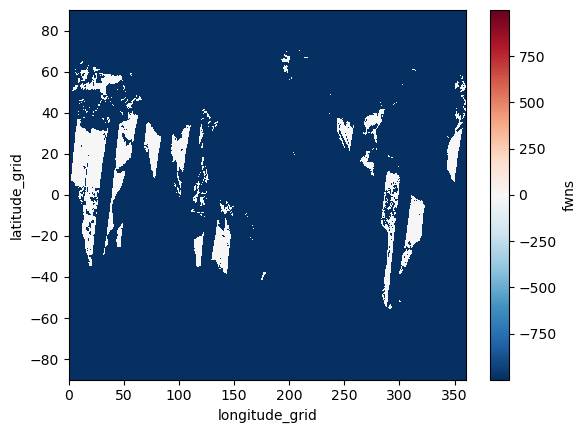

In [22]:
# Check for sanity
lpdr_ds_reduced['fwns'].plot()
plt.show()

#### WindSat preprocessing

`preprocess_windsat` prepares the WindSat NetCDF in five steps:

1. **Coordinate aliases**: `longitude` and `latitude` are aliased to `longitude_grid`/`latitude_grid` to enable an exact merge with the LPDR grid.
2. **Subsetting**: the dataset is reduced to the descending swath (`swath_sector=1`), fore look direction, 18.7 GHz (index 2) and 37 GHz (index 4) frequency bands, and V (index 0) and H (index 1) polarisations.
3. **Polarisation rename**: the `polarization_dual` dimension is renamed to `polarization` for consistency.
4. **Atmospheric corrections**: two surface brightness-temperature estimates are computed and added as new variables:
   - `tbboa_1st_order` — first-order approximation: $T_{B,BoA} = (T_{B,ToA} - T_{B,up}) / 	au$
   - `tbboa_de_lannoy` — two-stream formula (De Lannoy et al., 2016): $T_{B,BoA} = T_s \cdot \left[\frac{T_{B,ToA}}{	au} - \left(1 + \frac{1}{	au}\right) T_{B,up}\right] / (T_s - T_{B,up})$

In [23]:
# Load and preprocess a single day of WINDSAT data
windsat_ds_augmented = preprocess_windsat(f'{WINDSAT_DIR}/RSS_WINDSAT_DAILY_TBTOA_MAPS_2017_01_01.nc')

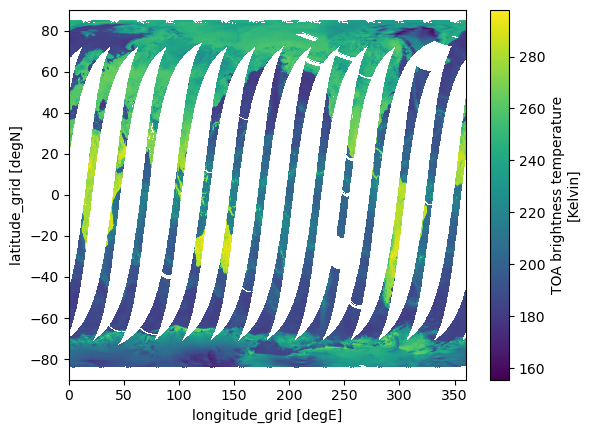

In [24]:
# Check for sanity
windsat_ds_augmented['tbtoa'].sel(polarization=0, frequency_band=0).plot()
plt.show()

#### Dataset merge and augmentation

Both datasets now share an identical 1440 × 720 geographic grid, so they are merged with `join="exact"`. The merged dataset is then augmented through three further steps:

1. **Lookup-table emissivities**: `load_lut` is called twice (once for H-pol, once for V-pol) to attach the reference land emissivity `ref_land_emis_de_lannoy_K_<pol>` to every pixel, indexed by the pixel's soil-moisture and VOD bin.
2. **Frequency/polarisation unravelling**: `unravel_freqpol` expands the `frequency_band × polarization` dimensions of `tbtoa`, `tran`, `tbdw`, `tbup`, `tbboa_1st_order`, and `tbboa_de_lannoy` into flat named variables (e.g. `tbtoa19H`, `tbboa_de_lannoy37V`). The original multi-dimensional variables are then dropped.
3. **Emissivity and surface water fraction**:
   - Per-channel emissivity: $e_{\text{freq,pol}} = T_{B,BoA,\text{freq,pol}} / T_s$ (De Lannoy et al., 2016)
   - Surface water fraction: $f_w = (e_{\text{ref,land}} - e_{19H}) / (e_{\text{ref,land}} - e_{\text{ref,water}})$, clipped to [0, 1]

In [25]:
# Merge the datasets
# join="exact" requires both datasets to share identical coordinate values.
# This is guaranteed because both have been reprojected to the same 0.25° global grid.
merged_ds = xr.merge([windsat_ds_augmented, lpdr_ds_reduced], join="exact")

In [26]:
merged_ds_augmented = merged_ds.copy()
merged_ds_augmented = load_lut(merged_ds_augmented, lut_filepath=LUT_H_PATH)
merged_ds_augmented = load_lut(merged_ds_augmented, lut_filepath=LUT_V_PATH)

# Unravel tbtoa and correction terms into individual frequency/polarisation arrays
# e.g. tbtoa → tbtoa19H, tbtoa19V, tbtoa37H, tbtoa37V
merged_ds_augmented = unravel_freqpol(merged_ds_augmented, dvars=['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])
merged_ds_augmented = merged_ds_augmented.drop_vars(['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])

# Cast unraveled vars to float32
_unraveled = [
    f"{v}{f}{p}"
    for v in ['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy']
    for f in ['19', '37'] for p in ['H', 'V']
]
for _var in _unraveled:
    merged_ds_augmented[_var] = merged_ds_augmented[_var].astype(np.float32)

# Compute de-Lannoy emissivity: e = TBBoA / Ts  (Ts = ERA5 skin temperature)
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        merged_ds_augmented[f"emiss{freq}{pol}_de_lannoy"] = (merged_ds_augmented[f"tbboa_de_lannoy{freq}{pol}"] / merged_ds_augmented["surtep_ERA5"]).astype(np.float32)

# Surface Water Fraction (SWF) calculation (De Lannoy et al., 2016):
merged_ds_augmented["fwns_calculated"] = ((merged_ds_augmented.ref_land_emis_de_lannoy_K_h - merged_ds_augmented.emiss19H_de_lannoy) / (merged_ds_augmented.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)
merged_ds_augmented["fwns_calculated"] = np.clip(merged_ds_augmented["fwns_calculated"], 0, 1)

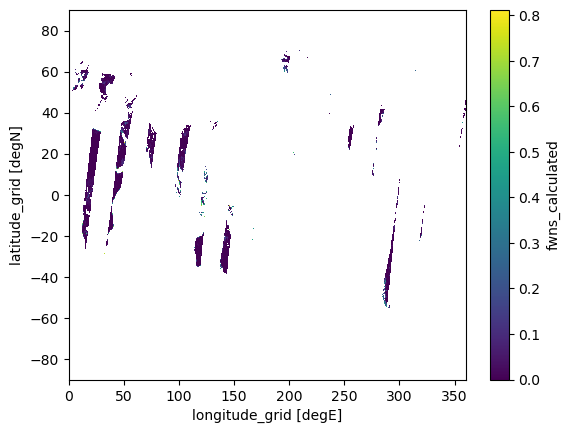

In [27]:
# Check for sanity
merged_ds_augmented['fwns_calculated'].plot()
plt.show()

#### Land mask integration

The [Global Lakes and Wetlands Database (GLWD)](https://www.worldwildlife.org/pages/global-lakes-and-wetlands-database) provides a 0.25° land-cover classification (`clase`) and the fractional area of each class per pixel (`porcentaje clase`). Two pre-processing steps precede the merge:

1. **Coastal class identification**: any land pixel adjacent (8-connected neighbourhood) to at least one sea pixel is assigned a new class equal to `max(clase) + 1`. This allows the model to treat land–sea boundary pixels separately from open land and open ocean.
2. **Exact merge**: both GLWD datasets are on the same 0.25° grid as the satellite data, so `join="exact"` is used.

`load_landmask` reads and latitude-sorts the two GLWD HDF5 files. `apply_landmask` performs the coastal dilation and merges both datasets into the main dataset. The landmask is loaded once outside the batch loop to avoid redundant file I/O.

In [28]:
# Load the GLWD landmask datasets once (reused here and in the main loop)
lm, lm_pct = load_landmask()

# Merge the landmask into the augmented dataset.
# Coastal pixels (land touching sea) are assigned a separate class via binary dilation.
merged_ds_final = apply_landmask(merged_ds_augmented, lm, lm_pct)

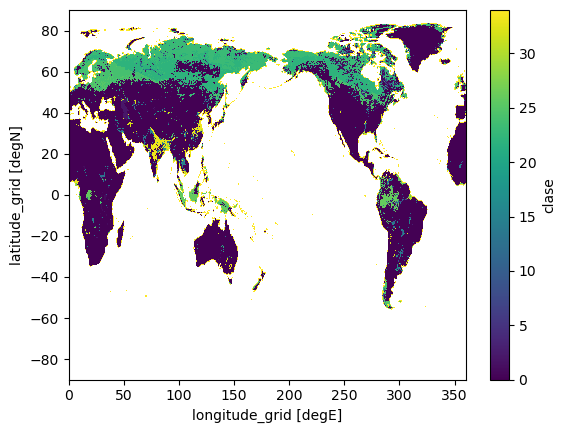

In [29]:
# Check for sanity
merged_ds_final['clase'].plot()
plt.show()

#### Quality filtering

Three validity filters are applied to remove pixels that carry no useful signal:

| Filter | Condition | Rationale |
|---|---|---|
| Land class | `clase` not null | Retains only pixels with a GLWD land classification; open-ocean pixels have no LPDR retrieval |
| Coastal exclusion | `clase ≠ 34` | Removes coastal mixed pixels (class 34 added by the dilation step) where the model assumptions break down |
| Valid soil moisture | `vsm > −995` | Removes LPDR no-data sentinel values for volumetric soil moisture |
| Valid atmospheric correction | `tbboa_de_lannoy19H` not null | Removes pixels where the two-stream correction failed (open ocean, high latitudes) |

### 3.2 Batch processing

The single-day pipeline is now applied to all 726 paired days. LPDR and WindSat files are paired by (year, day-of-year) using `group_files_by_day`; only days for which both a descending LPDR file and its quality-flag counterpart exist alongside a WindSat file are processed.

#### File pairing

`group_files_by_day` scans `LPDR_REP_DIR` and `WINDSAT_DIR` and returns a list of `[lpdr_path, qa_path, windsat_path]` triplets sorted by (year, DOY). Only descending-pass LPDR files (`*D.tif`) are retained; ascending passes (`*A.tif`) and bare quality-flag files are excluded.

**Why descending passes only?** The descending overpass occurs around 06:00 local solar time. At this hour the land surface has had several hours to equilibrate radiatively, making skin temperatures more stable and reducing the discrepancy between the ERA5 surface temperature used in the atmospheric correction and the actual radiometric temperature seen by the sensor.

In [106]:
corresponding_files = group_files_by_day(LPDR_REP_DIR, WINDSAT_DIR)

#### Processing loop

For each paired day the loop:

1. Preprocesses the LPDR descending file and its quality-flag counterpart.
2. Preprocesses the WindSat file.
3. Merges all three datasets on the shared 0.25° grid.
4. Applies LUTs (H and V polarisations) and unravels frequency/polarisation dimensions.
5. Computes per-channel emissivity and the surface water fraction estimate.
6. Integrates the GLWD land mask (pre-loaded once outside the loop).
7. Writes the result to `COMPLETE_DIR/WINDSAT_AMSRU_YYYY_DDD.nc`.

The land mask is loaded once before the loop to avoid 726 redundant file-open operations (~1.4 GB of re-read per full run). Total runtime is approximately 70 minutes.

In [107]:
output_dir = Path(COMPLETE_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

# Load the landmask once outside the loop to avoid redundant file I/O for each day
lm, lm_pct = load_landmask()

for files in tqdm(corresponding_files, desc="Processing days", unit="day"):
    # --- File names ---
    lpdr_D_data, qa_file, windsat_file = files

    # --- Year and day-of-year ---
    year, doy = get_year_and_doy(windsat_file)

    # --- Output path ---
    out_file = output_dir / f"WINDSAT_AMSRU_{year}_{doy}.nc"

    # --- Preprocess LPDR ---
    lpdr_ds = preprocess_lpdr(lpdr_D_data)
    qf_ds = preprocess_lpdr_quality_flag(qa_file)

    # --- Preprocess WINDSAT ---
    windsat_ds = preprocess_windsat(windsat_file)

    # --- Merge on the shared 0.25° grid ---
    merged_ds = xr.merge([windsat_ds, lpdr_ds, qf_ds], join="exact")

    # --- Apply LUTs and unravel frequency/polarisation ---
    merged_ds = load_lut(merged_ds, lut_filepath=LUT_H_PATH)
    merged_ds = load_lut(merged_ds, lut_filepath=LUT_V_PATH)

    merged_ds = unravel_freqpol(merged_ds, dvars=['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])
    merged_ds = merged_ds.drop_vars(['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy'])

    # Cast unraveled vars to float32
    _unraveled = [
        f"{v}{f}{p}"
        for v in ['tbtoa', 'tran', 'tbdw', 'tbup', 'tbboa_1st_order', 'tbboa_de_lannoy']
        for f in ['19', '37'] for p in ['H', 'V']
    ]
    for _var in _unraveled:
        merged_ds[_var] = merged_ds[_var].astype(np.float32)

    # --- Emissivity ---
    for freq in ["19", "37"]:
        for pol in ["H", "V"]:
            merged_ds[f"emiss{freq}{pol}_de_lannoy"] = (
                merged_ds[f"tbboa_de_lannoy{freq}{pol}"] / merged_ds["surtep_ERA5"]
            ).astype(np.float32)

    # --- Surface Water Fraction ---
    merged_ds["fwns_calculated"] = ((merged_ds.ref_land_emis_de_lannoy_K_h - merged_ds.emiss19H_de_lannoy) / (merged_ds.ref_land_emis_de_lannoy_K_h - REF_WATER_EMISS_H)).astype(np.float32)

    # --- Add landmask (pre-loaded) ---
    merged_ds = apply_landmask(merged_ds, lm, lm_pct)

    merged_ds.to_netcdf(out_file, format="NETCDF4")

Processing days: 100%|██████████| 726/726 [1:10:21<00:00,  5.81s/day]


A sample output file is loaded to confirm the expected structure. Each daily NetCDF has dimensions `(latitude_grid: 720, longitude_grid: 1440)` and 41 variables covering all brightness-temperature channels, atmospheric correction terms, emissivities, LPDR geophysical variables, the surface water fraction estimate, and the land-cover classification.

In [108]:
windsat_ds = xr.open_dataset(f"{COMPLETE_DIR}/WINDSAT_AMSRU_2017_001.nc", decode_times=time_coder)
windsat_ds

<xarray.Dataset> Size: 187MB
Dimensions:                      (latitude_grid: 720, longitude_grid: 1440)
Coordinates:
  * latitude_grid                (latitude_grid) float32 3kB -89.88 ... 89.88
  * longitude_grid               (longitude_grid) float32 6kB 0.125 ... 359.9
    sm_bin                       (latitude_grid, longitude_grid) int64 8MB ...
    vod_bin                      (latitude_grid, longitude_grid) int64 8MB ...
Data variables: (12/41)
    surtep_ERA5                  (latitude_grid, longitude_grid) float32 4MB ...
    fwns                         (latitude_grid, longitude_grid) float32 4MB ...
    Tmn                          (latitude_grid, longitude_grid) float32 4MB ...
    PWV                          (latitude_grid, longitude_grid) float32 4MB ...
    VOD                          (latitude_grid, longitude_grid) float32 4MB ...
    vsm                          (latitude_grid, longitude_grid) float32 4MB ...
    ...                           ...
    emiss19V_de_lannoy           (latitude_grid, longitude_grid) float32 4MB ...
    emiss37H_de_lannoy           (latitude_grid, longitude_grid) float32 4MB ...
    emiss37V_de_lannoy           (latitude_grid, longitude_grid) float32 4MB ...
    fwns_calculated              (latitude_grid, longitude_grid) float32 4MB ...
    clase                        (latitude_grid, longitude_grid) float32 4MB ...
    porcentaje clase             (latitude_grid, longitude_grid) float32 4MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

## 4. Data Filing

Machine-learning models expect flat tabular input. This section converts each daily NetCDF file into a Parquet file where every row represents one valid land pixel at a specific (latitude, longitude) location.

**Filters applied (mirroring Section 3.1):**

| Filter | Condition |
|---|---|
| Land class | `clase` not null |
| Coastal exclusion | `clase ≠ 34` |
| Valid soil moisture | `vsm > −995` |
| Valid surface water fraction | `fwns > −995` |
| Valid atmospheric correction | `tbboa_de_lannoy19H` not null |
| LPDR quality flag | Bits 1–5 of the 8-bit quality flag must all be zero; pixels with `quality_flag = 255` (fill) are also excluded |

**Engineered features added:**

| Feature | Formula | Purpose |
|---|---|---|
| `day_of_year` | integer DOY | Raw temporal index |
| `year` | integer year | Distinguishes 2017 from 2018 |
| `doy_sin`, `doy_cos` | $\sin/\cos(2\pi \cdot \text{DOY} / 365)$ | Cyclic encoding of seasonality |
| `lon_sin`, `lon_cos` | $\sin/\cos(2\pi \cdot \text{lon} / 360)$ | Cyclic encoding of longitude (avoids the 0°/360° discontinuity) |

The output is one Parquet file per day in `DATASET_DIR`, named `windsat_YYYY_DDD.parquet`.

In [9]:
files = sorted(glob.glob(f"{COMPLETE_DIR}/WINDSAT_AMSRU_*.nc"))

os.makedirs(DATASET_DIR, exist_ok=True)

for i, f in enumerate(tqdm(files, desc="Processing daily files")):
    ds = xr.open_dataset(f, decode_times=True)

    ds = ds.where(~ds.clase.isnull())
    ds = ds.where(ds['clase'] != 34)  # Exclude coastal pixels (class 34)
    ds = ds.where(ds["vsm"] > -995)
    ds = ds.where(ds["fwns"] > -995)
    ds = ds.where(~ds.tbboa_de_lannoy19H.isnull())

    df = ds.to_dataframe().reset_index()
    df.dropna(inplace=True)
    df.drop(columns=["sm_bin", "vod_bin"], inplace=True)

    day = int(f.split("_")[3].split(".")[0])
    df["day_of_year"] = np.float32(day)

    year = int(f.split("_")[2])
    df["year"] = np.float32(year)

    # Cyclic encoding of day-of-year to capture seasonality
    df["doy_sin"] = np.sin(2 * np.pi * day / 365.0).astype(np.float32)
    df["doy_cos"] = np.cos(2 * np.pi * day / 365.0).astype(np.float32)

    # Cyclic encoding of latitude and longitude to capture spatial relationships
    df["lon_sin"] = np.sin(2 * np.pi * df.longitude_grid / 360.0).astype(np.float32)
    df["lon_cos"] = np.cos(2 * np.pi * df.longitude_grid / 360.0).astype(np.float32)

    # Write ONE parquet file per day
    df.to_parquet(
        f"{DATASET_DIR}/windsat_{year}_{day:03d}.parquet",
        index=False
    )

Processing daily files: 100%|██████████| 726/726 [09:29<00:00,  1.28it/s]
